# EDA

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv('datos/demanda_electricidad_california_2019_2025.csv',
                parse_dates = ['period'])
df

,period,subba,subba-name,parent,parent-name,value,value-units
0,2019-01-01 00:00:00,PGAE,Pacific Gas and Electric,CISO,California Independent System Operator,10440,megawatthours
1,2019-01-01 00:00:00,SCE,Southern California Edison - CISO,CISO,California Independent System Operator,10287,megawatthours
2,2019-01-01 00:00:00,SDGE,San Diego Gas and Electric - CISO,CISO,California Independent System Operator,2414,megawatthours
3,2019-01-01 00:00:00,VEA,Valley Electric Association - CISO,CISO,California Independent System Operator,75,megawatthours
4,2019-01-01 01:00:00,PGAE,Pacific Gas and Electric,CISO,California Independent System Operator,11256,megawatthours
...,...,...,...,...,...,...,...
229140,2025-07-19 23:00:00,SCE,Southern California Edison,CISO,California Independent System Operator,13931,megawatthours
229141,2025-07-20 00:00:00,PGAE,Pacific Gas and Electric,CISO,California Independent System Operator,11336,megawatthours
229142,2025-07-20 00:00:00,SCE,Southern California Edison,CISO,California Independent System Operator,14393,megawatthours
229143,2025-07-20 00:00:00,SDGE,San Diego Gas and Electric,CISO,California Independent System Operator,1491,megawatthours


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 229145 entries, 0 to 229144
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   period       229145 non-null  datetime64[us]
 1   subba        229145 non-null  str           
 2   subba-name   229145 non-null  str           
 3   parent       229145 non-null  str           
 4   parent-name  229145 non-null  str           
 5   value        229145 non-null  int64         
 6   value-units  229145 non-null  str           
dtypes: datetime64[us](1), int64(1), str(5)
memory usage: 12.2 MB


## Agregación de periodos por suma de valores

In [25]:
df_gr = df.groupby('period')['value'].sum()
df_gr = df_gr.sort_index(ascending = True)
df_gr = pd.DataFrame(df_gr)
df_gr.head()

,value
period,
2019-01-01 00:00:00,23216
2019-01-01 01:00:00,24947
2019-01-01 02:00:00,27655
2019-01-01 03:00:00,27676
2019-01-01 04:00:00,26853


## Marcas de tiempo faltantes

#### 1. Observaciónes faltantes (valores NaN en la serie)

In [26]:
# indice ideal
indice_completo = pd.date_range(start = df_gr.index.min(), end = df_gr.index.max(), freq = 'h')

df_full = df_gr.reindex(indice_completo)

marcas_faltantes = df_full[df_full['value'].isna()]
print(f'indices faltantes: {len(marcas_faltantes)}') # valores NaN

indices faltantes: 118


Text(0.5, 1.0, 'Serie de tiempo interpolada')

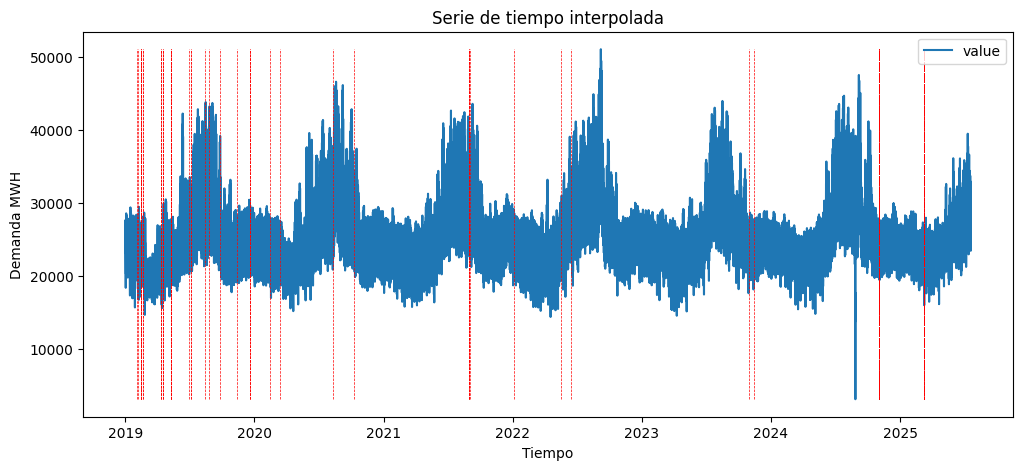

In [27]:
# Crear máscara con marcas de tiempo faltantes
mascara_faltantes = df_full['value'].isna()

# Graficar serie de tiempo (en azul)
fig, ax = plt.subplots(1,figsize=(12,5))
sns.lineplot(df_full, ax=ax)

# Graficar las marcas faltantes como líneas verticales en rojo
ymin = df_full['value'].min()
ymax = df_full['value'].max()
for ts in marcas_faltantes.index:
    ax.vlines(ts, ymin, ymax, colors='red', linestyles='dashed', linewidth=0.5)

ax.set_xlabel('Tiempo')
ax.set_ylabel('Demanda MWH')
ax.set_title('Serie de tiempo interpolada')

Las distribuciónes son aleatorias y no en bloques, por lo que se puede imputar interpolando

## Interpolación

Text(0.5, 1.0, 'Serie de tiempo interpolada')

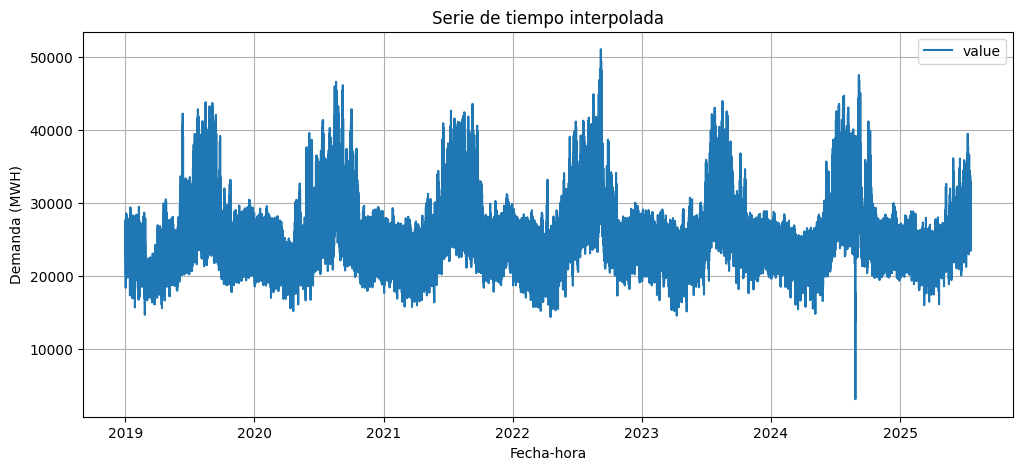

In [29]:
df_inerpol = df_full.interpolate(method = 'linear')

fig, ax = plt.subplots(1,figsize=(12,5))
sns.lineplot(df_inerpol, ax=ax)
ax.grid()
ax.set_xlabel('Fecha-hora')
ax.set_ylabel('Demanda (MWH)')
ax.set_title('Serie de tiempo interpolada')